# Advanced Plots and Customization

---

### Table of Contents
1. Introduction
2. Bivariate Plots with Marginal Distributions (`sns.jointplot`)
3. Visualizing Pairwise Relationships (`sns.pairplot`)
4. Customizing Seaborn Plots with Matplotlib

---

## 1. Introduction
- This final lesson covers some of Seaborn's most powerful automated plotting functions
  and demonstrates how to combine Seaborn's high-level interface with Matplotlib's
  low-level control for ultimate customization.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Setup: Apply a theme for our plot ---
sns.set_theme(style="whitegrid")


--

## 2. Bivariate Plots with Marginal Distributions (`sns.jointplot`)
- `jointplot` is a powerful function that creates a central scatter plot to show the
  relationships between two variables, plus marginal plots (histograms or KDEs)
  on the top and right axes to show the distribution of each individual variable.
- It creates and manages its own figure.

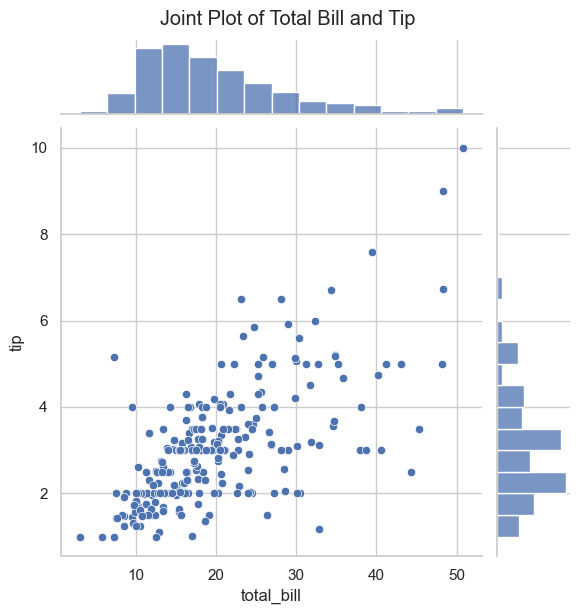

In [2]:
tips_df = sns.load_dataset("tips")

# --- Create a joint plot ---
# The default shows a scatter plot in the center and histograms on the margins.
sns.jointplot(data=tips_df, x="total_bill", y="tip")
plt.suptitle("Joint Plot of Total Bill and Tip", y=1.02)  # Add a title

plt.show()

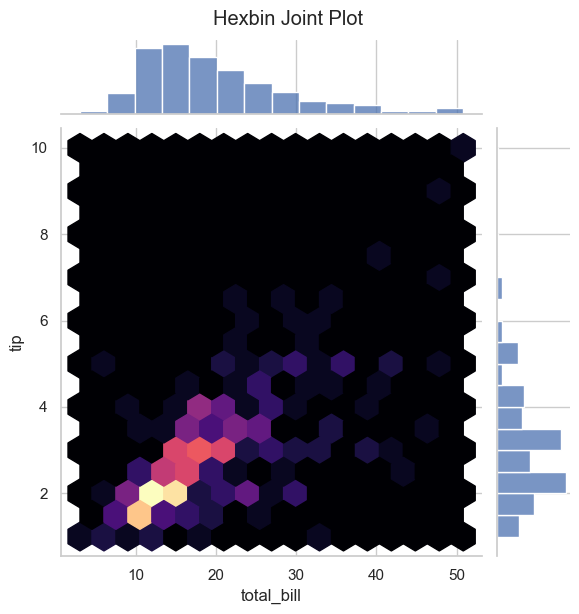

In [3]:
# -- Change the kind of plot in the center ---
# `kind='hex'` creates a 2D hexbin plot, useful for dense data.
sns.jointplot(data=tips_df, x="total_bill", y="tip", kind="hex", cmap="magma")
plt.suptitle("Hexbin Joint Plot", y=1.02)
plt.show()


---

## 3. Visualizing Pairwise Relationships (`sns.pairplot`)
- A `pairplot` is a classic tool for exploratory data analysis (EDA).
- It creates a grid of plots showing the relationship between every pair of
  variables in a dataset.
- It shows scatter plots on the off-diagonals and distribution plots (histograms
  or KDEs) on the diagonal.

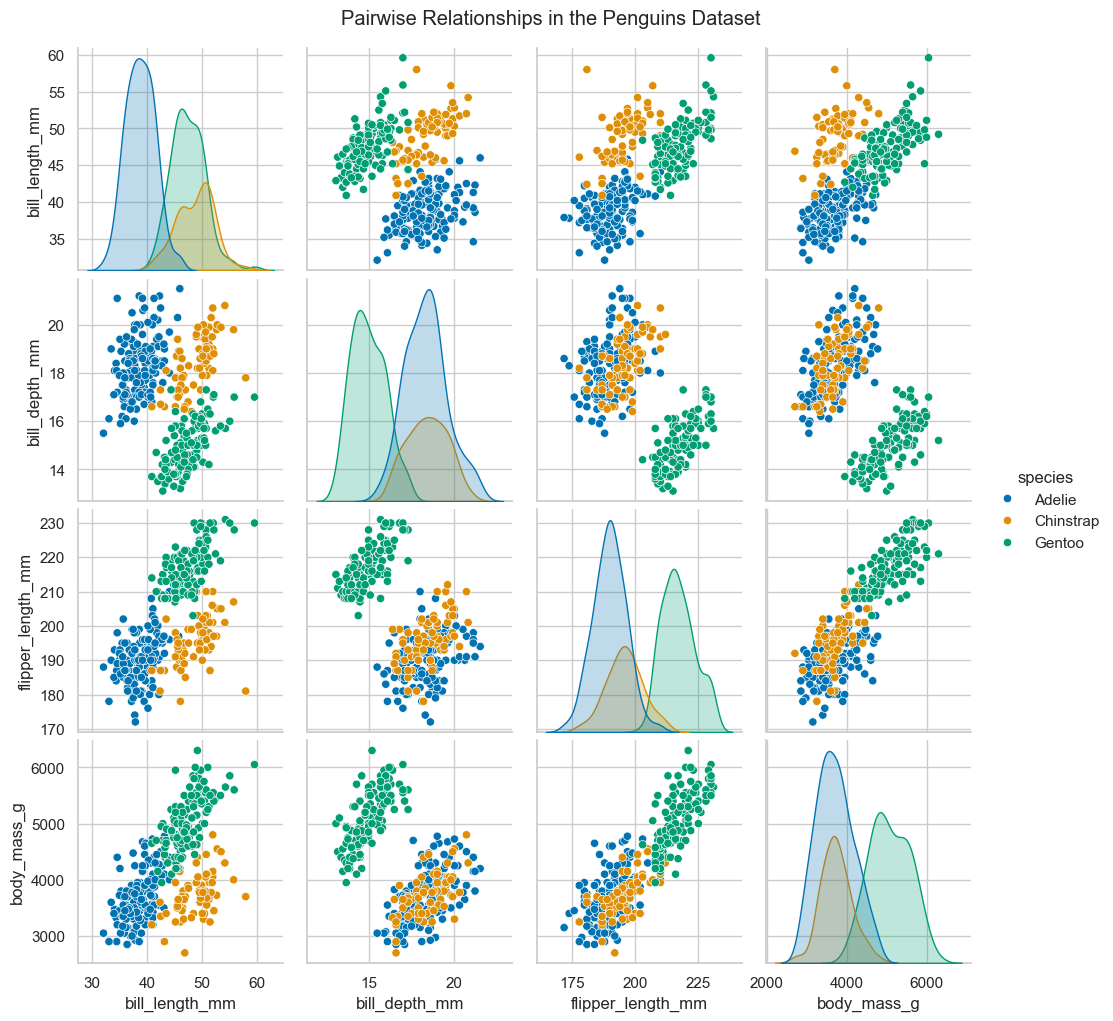

In [4]:
penguins_df = sns.load_dataset("penguins")

# --- Create a pair plot ---
# `hue='species'` is the key feature here. It colors every plot by the species,
# allowing for instant comparison across all variable relationships.
sns.pairplot(data=penguins_df, hue="species", palette="colorblind")
plt.suptitle("Pairwise Relationships in the Penguins Dataset", y=1.02)
plt.show()


---

## 4. Customizing Seaborn Plots with Matplotlib
- Seaborn plots are Matplotlib objects. This means you can use Matplotlib's
  functions to get fine-grained control over a plot's appearance after it's created.

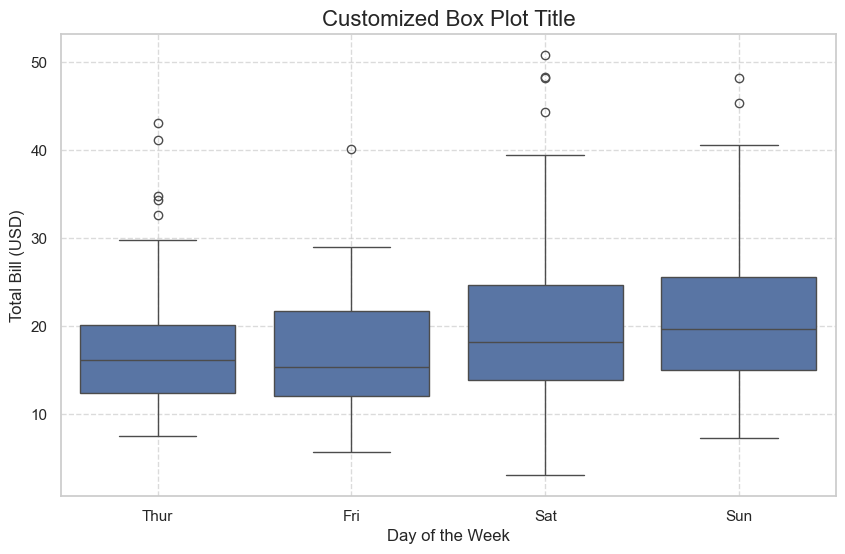

In [6]:
# --- Method 1: Customizing an "axes-level" plot
# Functions like `boxplot`, `scatterplot`, etc., can be drawn on a specific Matplotlib axes.

# First, create a Matplotlib figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# Second, tell Seaborn to draw its plot on our specific `ax`
sns.boxplot(data=tips_df, x="day", y="total_bill", ax=ax)

# Third, use `ax` methods to customize the plot further
ax.set_title("Customized Box Plot Title", fontsize=16)
ax.set_xlabel("Day of the Week", fontsize=12)
ax.set_ylabel("Total Bill (USD)", fontsize=12)
ax.grid(linestyle="--", alpha=0.7)

plt.show()

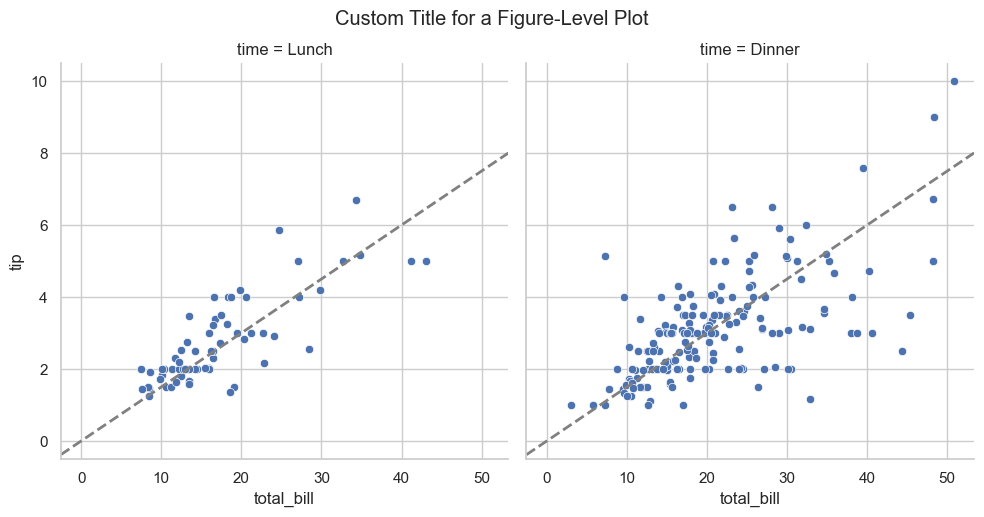

In [7]:
# --- Method 2: Customizing a "figure-level" plot ---
# Functions like `pairplot` or `relplot` return a Grid object.
# You can access the figure through the `.figure` attribute.
g = sns.relplot(data=tips_df, x="total_bill", y="tip", col="time")
g.figure.suptitle("Custom Title for a Figure-Level Plot", y=1.03)
# You can also iterate through the axes in the grid
for ax in g.axes.flat:
    ax.axline(
        (0, 0), slope=0.15, color="gray", lw=2, linestyle="--"
    )  # Add a reference line
plt.show()